In [2]:
# =========================================================
# Project Title: Hospital Resource Utilization & Readmission Tracker
# Product Brand Name: "MediFlow Cloud"
# Week 2: Serverless ETL (Pandas-based implementation)
#
# Purpose:
# - Simulate AWS Glue + Athena transformation logic using Pandas
# - Clean and transform raw healthcare data
# - Engineer ALOS and 30-day readmission features
# - Build dashboard-ready processed outputs
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# STEP 1: LOAD RAW DATASETS
# Purpose:
# - Load all required source tables for ETL processing
# =========================================================

patients = pd.read_csv(r"C:\Users\Satya\Downloads\Hospital+Patient+Records\patients.csv")
encounters = pd.read_csv(r"C:\Users\Satya\Downloads\Hospital+Patient+Records\encounters.csv")
procedures = pd.read_csv(r"C:\Users\Satya\Downloads\Hospital+Patient+Records\procedures.csv")
organizations = pd.read_csv(r"C:\Users\Satya\Downloads\Hospital+Patient+Records\organizations.csv")

print("Datasets loaded successfully ✅")

# =========================================================
# STEP 2: BASIC SCHEMA CHECK
# Purpose:
# - Verify row counts and available columns
# - Confirm tables are loaded correctly
# =========================================================

print("\nPatients Shape:", patients.shape)
print("Encounters Shape:", encounters.shape)
print("Procedures Shape:", procedures.shape)
print("Organizations Shape:", organizations.shape)


print("Patients columns:", patients.columns.tolist())
print("Encounters columns:", encounters.columns.tolist())
print("Procedures columns:", procedures.columns.tolist())
print("Organizations columns:", organizations.columns.tolist())

Datasets loaded successfully ✅

Patients Shape: (974, 20)
Encounters Shape: (27891, 14)
Procedures Shape: (47701, 9)
Organizations Shape: (1, 8)
Patients columns: ['Id', 'BIRTHDATE', 'DEATHDATE', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON']
Encounters columns: ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']
Procedures columns: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']
Organizations columns: ['Id', 'NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'LAT', 'LON']


In [3]:
# =========================================================
# STEP 3: REMOVE DUPLICATE ROWS
# Purpose:
# - Prevent duplicate records from affecting KPIs and joins
# =========================================================

patients = patients.drop_duplicates()
encounters = encounters.drop_duplicates()
procedures = procedures.drop_duplicates()
organizations = organizations.drop_duplicates()

print("Duplicates removed ✅")


# =========================================================
# STEP 4: SELECT ONLY REQUIRED COLUMNS
# Purpose:
# - Reduce unnecessary processing
# - Simulate Athena scan optimization by keeping only useful fields
# =========================================================

# Patients
patients = patients[
    ['Id', 'BIRTHDATE', 'DEATHDATE', 'GENDER', 'RACE', 'ETHNICITY',
     'CITY', 'STATE', 'COUNTY', 'ZIP']
].copy()

# Encounters
encounters = encounters[
    ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 
     'ENCOUNTERCLASS', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
     'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']
].copy()


# Procedures
procedures = procedures[
    ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION',
     'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']
].copy()


# Organizations
organizations = organizations[
    ['Id', 'NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'LAT', 'LON']
].copy()


print("Selected important columns only ✅")

Duplicates removed ✅
Selected important columns only ✅


In [4]:
# =========================================================
# STEP 5: RENAME COLUMNS FOR CLARITY
# Purpose:
# - Make field names more readable and analysis-friendly
# =========================================================


patients = patients.rename(columns={
    'Id': 'patient_id',
    'BIRTHDATE': 'birth_date',
    'DEATHDATE': 'death_date',
    'GENDER': 'gender',
    'RACE': 'race',
    'ETHNICITY': 'ethnicity',
    'CITY': 'patient_city',
    'STATE': 'patient_state',
    'COUNTY': 'patient_county',
    'ZIP': 'patient_zip'
})

encounters = encounters.rename(columns={
    'Id': 'encounter_id',
    'START': 'admit_date',
    'STOP': 'discharge_date',
    'PATIENT': 'patient_id',
    'ORGANIZATION': 'hospital_id',
    'PAYER': 'payer_id',
    'ENCOUNTERCLASS': 'encounter_class',
    'DESCRIPTION': 'encounter_description',
    'BASE_ENCOUNTER_COST': 'base_encounter_cost',
    'TOTAL_CLAIM_COST': 'total_claim_cost',
    'PAYER_COVERAGE': 'payer_coverage',
    'REASONCODE': 'reason_code',
    'REASONDESCRIPTION': 'reason_description'
})

procedures = procedures.rename(columns={
    'START': 'procedure_start',
    'STOP': 'procedure_stop',
    'PATIENT': 'patient_id',
    'ENCOUNTER': 'encounter_id',
    'CODE': 'procedure_code',
    'DESCRIPTION': 'procedure_description',
    'BASE_COST': 'procedure_base_cost',
    'REASONCODE': 'procedure_reason_code',
    'REASONDESCRIPTION': 'procedure_reason_description'
})

organizations = organizations.rename(columns={
    'Id': 'hospital_id',
    'NAME': 'hospital_name',
    'ADDRESS': 'hospital_address',
    'CITY': 'hospital_city',
    'STATE': 'hospital_state',
    'ZIP': 'hospital_zip',
    'LAT': 'hospital_lat',
    'LON': 'hospital_lon'
})

print("\nColumns renamed successfully ✅")


Columns renamed successfully ✅


In [5]:
# =========================================================
# STEP 6: CONVERT DATE COLUMNS
# Purpose:
# - Required for age calculation, LOS calculation, and readmission logic
# =========================================================

patients['birth_date'] = pd.to_datetime(patients['birth_date'], errors='coerce')
patients['death_date'] = pd.to_datetime(patients['death_date'], errors='coerce')

encounters['admit_date'] = pd.to_datetime(encounters['admit_date'], errors='coerce')
encounters['discharge_date'] = pd.to_datetime(encounters['discharge_date'], errors='coerce')

procedures['procedure_start'] = pd.to_datetime(procedures['procedure_start'], errors='coerce')
procedures['procedure_stop'] = pd.to_datetime(procedures['procedure_stop'], errors='coerce')

print("\nDate conversion completed ✅")


Date conversion completed ✅


In [6]:
# =========================================================
# STEP 7: CHECK MISSING VALUES
# Purpose:
# - Identify which columns need cleaning
# =========================================================

print("\nMissing values in Patients:\n", patients.isnull().sum())
print("\nMissing values in Encounters:\n", encounters.isnull().sum())
print("\nMissing values in Procedures:\n", procedures.isnull().sum())
print("\nMissing values in Organizations:\n", organizations.isnull().sum())



Missing values in Patients:
 patient_id          0
birth_date          0
death_date        820
gender              0
race                0
ethnicity           0
patient_city        0
patient_state       0
patient_county      0
patient_zip       142
dtype: int64

Missing values in Encounters:
 encounter_id                 0
admit_date                   0
discharge_date               0
patient_id                   0
hospital_id                  0
encounter_class              0
encounter_description        0
base_encounter_cost          0
total_claim_cost             0
payer_coverage               0
reason_code              19541
reason_description       19541
dtype: int64

Missing values in Procedures:
 procedure_start                     0
procedure_stop                      0
patient_id                          0
encounter_id                        0
procedure_code                      0
procedure_description               0
procedure_base_cost                 0
procedure_reason_code 

In [7]:
# =========================================================
# STEP 8: HANDLE MISSING VALUES
# Purpose:
# - Fill only where it makes sense
# - Keep date nulls as null if they are genuinely missing
# =========================================================

# Patients table
patients['patient_zip'] = patients['patient_zip'].fillna('Unknown')
patients['gender'] = patients['gender'].fillna('Unknown')
patients['race'] = patients['race'].fillna('Unknown')
patients['ethnicity'] = patients['ethnicity'].fillna('Unknown')
patients['patient_city'] = patients['patient_city'].fillna('Unknown')
patients['patient_state'] = patients['patient_state'].fillna('Unknown')
patients['patient_county'] = patients['patient_county'].fillna('Unknown')

# Encounters table
encounters['encounter_class'] = encounters['encounter_class'].fillna('Unknown')
encounters['encounter_description'] = encounters['encounter_description'].fillna('Unknown')
encounters['reason_description'] = encounters['reason_description'].fillna('Not Specified')
# Numeric cost columns: fill with 0 only if missing
encounters['base_encounter_cost'] = encounters['base_encounter_cost'].fillna(0)
encounters['total_claim_cost'] = encounters['total_claim_cost'].fillna(0)
encounters['payer_coverage'] = encounters['payer_coverage'].fillna(0)


# Procedures table
procedures['procedure_code'] = procedures['procedure_code'].fillna('Unknown')
procedures['procedure_description'] = procedures['procedure_description'].fillna('Unknown')
procedures['procedure_base_cost'] = procedures['procedure_base_cost'].fillna(0)
procedures['procedure_reason_description'] = procedures['procedure_reason_description'].fillna('Not Specified')

# Organizations table
# No missing values currently, but safe fallback
organizations['hospital_name'] = organizations['hospital_name'].fillna('Unknown')
organizations['hospital_address'] = organizations['hospital_address'].fillna('Unknown')
organizations['hospital_city'] = organizations['hospital_city'].fillna('Unknown')
organizations['hospital_state'] = organizations['hospital_state'].fillna('Unknown')
organizations['hospital_zip'] = organizations['hospital_zip'].fillna('Unknown')

print("Missing values handled ✅")


Missing values handled ✅


In [8]:
# =========================================================
# STEP 9: CREATE AGE COLUMN
# Purpose:
# - Derive patient age for readmission and demographic analysis
# =========================================================

today = pd.Timestamp.today()
patients['age'] = ((today - patients['birth_date']).dt.days / 365).astype('float')

# Create age groups for dashboard segmentation
patients['age_group'] = pd.cut(
    patients['age'],
    bins=[0, 18, 35, 50, 65, 120],
    labels=['0-18', '19-35', '36-50', '51-65', '65+']
)

print("\nAge and age group created ✅")


Age and age group created ✅


In [9]:
# =========================================================
# STEP 10: CALCULATE LENGTH OF STAY (LOS)
# Purpose:
# - Core hospital utilization metric
# =========================================================

encounters['los_days'] = (
    encounters['discharge_date'] - encounters['admit_date']
).dt.days

# Replace invalid negative LOS values with NaN
encounters.loc[encounters['los_days'] < 0, 'los_days'] = np.nan

print("Length of Stay calculated ✅")


Length of Stay calculated ✅


In [10]:
# =========================================================
# STEP 11: CREATE 30-DAY READMISSION FLAG (REFINED VERSION)
# Purpose:
# - Identify whether a patient is readmitted within 30 days after discharge from an inpatient stay
# - Restricting to inpatient encounters ensures that
#   readmission metrics reflect actual hospital admissions and not outpatient or short visits
# =========================================================

# ---------------------------------------------------------
#  Filter only inpatient encounters
# ---------------------------------------------------------
inpatient_encounters = encounters[
    encounters['encounter_class'].str.lower() == 'inpatient'
].copy()

# ---------------------------------------------------------
#  Keep only valid hospital stays
# (exclude same-day or invalid LOS)
# ---------------------------------------------------------
inpatient_encounters['los_days'] = (
    inpatient_encounters['discharge_date'] - inpatient_encounters['admit_date']
).dt.days

inpatient_encounters = inpatient_encounters[
    inpatient_encounters['los_days'] > 0
].copy()

# ---------------------------------------------------------
#  Sort by patient and admission date
# ---------------------------------------------------------
inpatient_encounters = inpatient_encounters.sort_values(
    by=['patient_id', 'admit_date']
).reset_index(drop=True)

# ---------------------------------------------------------
#  Get next admission date for each patient
# ---------------------------------------------------------
inpatient_encounters['next_admission_date'] = inpatient_encounters.groupby(
    'patient_id'
)['admit_date'].shift(-1)

# ---------------------------------------------------------
#  Calculate gap between discharge and next admission
# ---------------------------------------------------------
inpatient_encounters['days_to_next_admission'] = (
    inpatient_encounters['next_admission_date'] -
    inpatient_encounters['discharge_date']
).dt.days

# ---------------------------------------------------------
#  Create readmission flag 
# - Must be between 1 and 30 days
# - Avoid same-day re-entry noise
# ---------------------------------------------------------
inpatient_encounters['readmitted_30d'] = inpatient_encounters[
    'days_to_next_admission'
].apply(
    lambda x: 1 if pd.notnull(x) and 1 <= x <= 30 else 0
)

print("30-day readmission flag created ✅")

30-day readmission flag created ✅


In [11]:
# -----------------------------------
# STEP 12: Merge readmission flag into encounters
# Purpose:
# - Add inpatient-based readmission flag to full encounters data
# - Non-inpatient encounters ki readmission = 0 assign chestham
# -----------------------------------

encounters = encounters.merge(
    inpatient_encounters[['encounter_id', 'readmitted_30d']],
    on='encounter_id',
    how='left'
)

# Fill null values (non-inpatient encounters)
encounters['readmitted_30d'] = encounters['readmitted_30d'].fillna(0)

print("\nReadmission flag merged successfully ✅")

# =========================================================
# STEP 12A: MERGE PATIENTS + ENCOUNTERS
# Purpose:
# - Combine encounter-level data with patient demographics
# =========================================================

patient_encounters = encounters.merge(
    patients,
    on='patient_id',
    how='left'
)

print("\nPatients + Encounters merged ✅")
print("Merged Shape:", patient_encounters.shape)


# =========================================================
# STEP 13: MERGE HOSPITAL / ORGANIZATION DATA
# Purpose:
# - Add hospital name, address, and geospatial attributes
# =========================================================

full_data = patient_encounters.merge(
    organizations,
    on='hospital_id',
    how='left'
)

print("\nHospital data merged ✅")
print("Full Data Shape:", full_data.shape)


# =========================================================
# STEP 14: PROCEDURE AGGREGATION
# Purpose:
# - Convert multiple procedure rows into encounter-level summary metrics
# =========================================================

procedure_summary = procedures.groupby('encounter_id').agg(
    total_procedures=('procedure_code', 'count'),
    avg_procedure_cost=('procedure_base_cost', 'mean'),
    total_procedure_cost=('procedure_base_cost', 'sum')
).reset_index()

print("\nProcedure summary created ✅")


# =========================================================
# STEP 15: MERGE PROCEDURE SUMMARY INTO FINAL DATA
# Purpose:
# - Add procedure count and procedure cost metrics
# =========================================================

full_data = full_data.merge(
    procedure_summary,
    on='encounter_id',
    how='left'
)

print("\nProcedure summary merged ✅")
print("Updated Full Data Shape:", full_data.shape)



Readmission flag merged successfully ✅

Patients + Encounters merged ✅
Merged Shape: (27891, 25)

Hospital data merged ✅
Full Data Shape: (27891, 32)

Procedure summary created ✅

Procedure summary merged ✅
Updated Full Data Shape: (27891, 35)


In [12]:
# =========================================================
# STEP 16: FILL NUMERIC NULLS AFTER MERGE
# Purpose:
# - Replace missing numeric summary values with 0
# =========================================================

numeric_cols = [
    'base_encounter_cost',
    'total_claim_cost',
    'payer_coverage',
    'los_days',
    'total_procedures',
    'avg_procedure_cost',
    'total_procedure_cost'
]

for col in numeric_cols:
    if col in full_data.columns:
        full_data[col] = full_data[col].fillna(0)

print("\nNumeric null values handled ✅")


Numeric null values handled ✅


In [13]:
# =========================================================
# STEP 17: CREATE KPI SUMMARY TABLES
# Purpose:
# - Prepare dashboard-ready aggregated outputs
# =========================================================

# Department / encounter class summary
encounter_class_summary = full_data.groupby('encounter_class').agg(
    total_patients=('patient_id', 'nunique'),
    total_encounters=('encounter_id', 'nunique'),
    avg_los=('los_days', 'mean'),
    readmission_rate=('readmitted_30d', 'mean'),
    avg_claim_cost=('total_claim_cost', 'mean')
).reset_index()

encounter_class_summary['readmission_rate'] = encounter_class_summary['readmission_rate'] * 100

# Age group summary
age_group_summary = full_data.groupby('age_group', observed=False).agg(
    total_patients=('patient_id', 'nunique'),
    total_encounters=('encounter_id', 'nunique'),
    avg_los=('los_days', 'mean'),
    readmission_rate=('readmitted_30d', 'mean'),
    avg_claim_cost=('total_claim_cost', 'mean')
).reset_index()

age_group_summary['readmission_rate'] = age_group_summary['readmission_rate'] * 100

# Hospital summary
hospital_summary = full_data.groupby(
    ['hospital_id', 'hospital_name', 'hospital_city', 'hospital_state', 'hospital_lat', 'hospital_lon']
).agg(
    total_patients=('patient_id', 'nunique'),
    total_encounters=('encounter_id', 'nunique'),
    avg_los=('los_days', 'mean'),
    readmission_rate=('readmitted_30d', 'mean'),
    total_claim_amount=('total_claim_cost', 'sum')
).reset_index()

hospital_summary['readmission_rate'] = hospital_summary['readmission_rate'] * 100

print("\nSummary tables created ✅")


Summary tables created ✅


In [14]:
# =========================================================
# STEP 18: CREATE COST ANALYSIS DATASET
# Purpose:
# - Curated file for hospital cost and readmission analysis
# =========================================================

cost_analysis = full_data[
    ['encounter_id', 'patient_id', 'hospital_id', 'hospital_name',
     'encounter_class', 'encounter_description', 'base_encounter_cost',
     'total_claim_cost', 'payer_coverage', 'readmitted_30d',
     'los_days', 'age', 'age_group', 'gender', 'race',
     'patient_city', 'patient_state']
].copy()

print("\nCost analysis dataset ready ✅")


Cost analysis dataset ready ✅


In [15]:
# =========================================================
# STEP 19: CREATE EXTRA SUMMARY TABLES
# Purpose:
# - Support predictive and dashboard analysis
# =========================================================

# Readmission by age group
readmission_summary = full_data.groupby('age_group', observed=False).agg(
    total_patients=('patient_id', 'nunique'),
    total_encounters=('encounter_id', 'nunique'),
    avg_los=('los_days', 'mean'),
    readmission_rate=('readmitted_30d', 'mean')
).reset_index()

readmission_summary['readmission_rate'] = readmission_summary['readmission_rate'] * 100

# Cost summary by encounter class
cost_summary = full_data.groupby('encounter_class').agg(
    avg_base_cost=('base_encounter_cost', 'mean'),
    avg_claim_cost=('total_claim_cost', 'mean'),
    avg_payer_coverage=('payer_coverage', 'mean'),
    total_claim_amount=('total_claim_cost', 'sum')
).reset_index()

# LOS bucket for utilization / readmission patterns
full_data['los_bucket'] = pd.cut(
    full_data['los_days'],
    bins=[-1, 1, 3, 7, 14, 1000],
    labels=['0-1 days', '2-3 days', '4-7 days', '8-14 days', '15+ days']
)

los_summary = full_data.groupby('los_bucket', observed=False).agg(
    total_encounters=('encounter_id', 'nunique'),
    avg_claim_cost=('total_claim_cost', 'mean'),
    readmission_rate=('readmitted_30d', 'mean')
).reset_index()

los_summary['readmission_rate'] = los_summary['readmission_rate'] * 100

print("\nAdditional summary tables created ✅")


Additional summary tables created ✅


In [16]:
# =========================================================
# STEP 20: FINAL VALIDATION
# Purpose:
# - Preview outputs before saving
# =========================================================

print("\nFinal Data Preview:")
print(full_data.head())

print("\nEncounter Class Summary Preview:")
print(encounter_class_summary.head())

print("\nAge Group Summary Preview:")
print(age_group_summary.head())

print("\nHospital Summary Preview:")
print(hospital_summary.head())

print("\nReadmission Summary Preview:")
print(readmission_summary.head())

print("\nCost Summary Preview:")
print(cost_summary.head())

print("\nLOS Summary Preview:")
print(los_summary.head())



Final Data Preview:
                           encounter_id                admit_date  \
0  32c84703-2481-49cd-d571-3899d5820253 2011-01-02 09:26:36+00:00   
1  c98059da-320a-c0a6-fced-c8815f3e3f39 2011-01-03 05:44:39+00:00   
2  4ad28a3a-2479-782b-f29c-d5b3f41a001e 2011-01-03 14:32:11+00:00   
3  c3f4da61-e4b4-21d5-587a-fbc89943bc19 2011-01-03 16:24:45+00:00   
4  a9183b4f-2572-72ea-54c2-b3cd038b4be7 2011-01-03 17:36:53+00:00   

             discharge_date                            patient_id  \
0 2011-01-02 12:58:36+00:00  3de74169-7f67-9304-91d4-757e0f3a14d2   
1 2011-01-03 06:01:42+00:00  d9ec2e44-32e9-9148-179a-1653348cc4e2   
2 2011-01-03 14:47:11+00:00  73babadf-5b2b-fee7-189e-6f41ff213e01   
3 2011-01-03 16:39:45+00:00  3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b   
4 2011-01-03 17:51:53+00:00  fa006887-d93c-d302-8b89-f3c25f88c0e1   

                            hospital_id encounter_class  \
0  d78e84ec-30aa-3bba-a33a-f29a3a454662      ambulatory   
1  d78e84ec-30aa-3bba-a33a-f29a

In [17]:
# =========================================================
# STEP 21: SAVE PROCESSED OUTPUTS
# Purpose:
# - These files act as staging / processed outputs
# - These will be used in Power BI
# =========================================================

full_data.to_csv("processed_full_data.csv", index=False)
encounter_class_summary.to_csv("processed_encounter_class_summary.csv", index=False)
age_group_summary.to_csv("processed_age_group_summary.csv", index=False)
hospital_summary.to_csv("processed_hospital_summary.csv", index=False)
cost_analysis.to_csv("processed_cost_analysis.csv", index=False)
readmission_summary.to_csv("processed_readmission_summary.csv", index=False)
cost_summary.to_csv("processed_cost_summary.csv", index=False)
los_summary.to_csv("processed_los_summary.csv", index=False)

print("\nAll processed files saved successfully ✅")


All processed files saved successfully ✅


In [18]:
# =========================================================
# STEP 22: FILTER INPATIENT ENCOUNTERS FOR FINAL HOSPITAL KPIs
# Purpose:
# - The project focuses on hospital resource utilization, Average Length of Stay (ALOS), and 30-day readmission.
# - These KPIs are most meaningful for inpatient admissions, because outpatient, wellness, ambulatory, and urgent care
#   visits are usually short-duration encounters and can distort hospital-level KPI calculations.
# - This step creates a separate inpatient-only dataset for realistic final KPI reporting.
# =========================================================

inpatient_data = full_data[
    full_data['encounter_class'].str.lower() == 'inpatient'
].copy()

print("\nInpatient-only dataset created ✅")
print("Inpatient records count:", inpatient_data.shape)


Inpatient-only dataset created ✅
Inpatient records count: (1135, 36)


In [19]:
# =========================================================
# STEP 23: FINAL KPI CHECK USING INPATIENT DATA
# Purpose:
# - Generate realistic hospital KPIs for final reporting
# - Restricting KPI calculation to inpatient encounters gives
#   a more accurate picture of bed utilization, ALOS, and
#   30-day readmission risk
# =========================================================

print("\n===== KPI SUMMARY (INPATIENT ONLY) =====")

print("Total Inpatient Patients:", inpatient_data['patient_id'].nunique())
print("Total Inpatient Encounters:", inpatient_data['encounter_id'].nunique())
print("Average LOS (Inpatient):", round(inpatient_data['los_days'].mean(), 2))
print("Readmission Rate (%) (Inpatient):", round(inpatient_data['readmitted_30d'].mean() * 100, 2))
print("Total Claim Amount (Inpatient):", round(inpatient_data['total_claim_cost'].sum(), 2))


===== KPI SUMMARY (INPATIENT ONLY) =====
Total Inpatient Patients: 153
Total Inpatient Encounters: 1135
Average LOS (Inpatient): 1.53
Readmission Rate (%) (Inpatient): 25.2
Total Claim Amount (Inpatient): 8809134.34


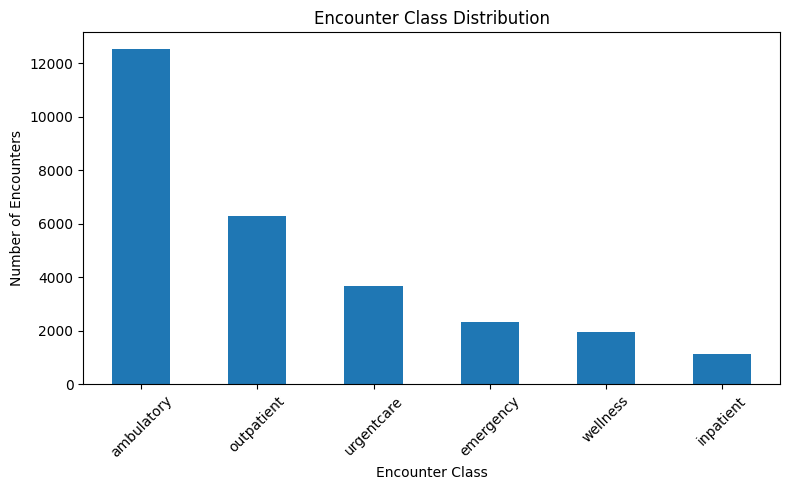

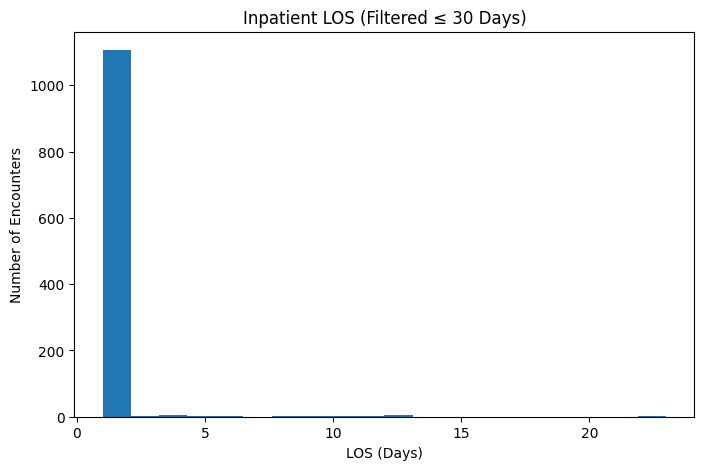


Week 2 validation visualizations generated successfully ✅


In [20]:
# =========================================================
# STEP 24: WEEK 2 VALIDATION VISUALIZATIONS
# Purpose:
# - Validate ETL output before final dashboard development
# =========================================================

# Encounter Class Distribution
encounter_counts = full_data['encounter_class'].value_counts()

plt.figure(figsize=(8, 5))
encounter_counts.plot(kind='bar')
plt.title('Encounter Class Distribution')
plt.xlabel('Encounter Class')
plt.ylabel('Number of Encounters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Inpatient LOS Distribution
inpatient_filtered = inpatient_data[inpatient_data['los_days'] <= 30]

plt.figure(figsize=(8,5))
inpatient_filtered['los_days'].plot(kind='hist', bins=20)
plt.title('Inpatient LOS (Filtered ≤ 30 Days)')
plt.xlabel('LOS (Days)')
plt.ylabel('Number of Encounters')
plt.show()

print("\nWeek 2 validation visualizations generated successfully ✅")

In [21]:
full_data['hospital_name'].unique()

array(['MASSACHUSETTS GENERAL HOSPITAL'], dtype=object)